## 07 - Perbandingan CNN Scratch vs MobileNetV2

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

DIR_FIGURES = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

DIR_FIGURES.mkdir(
    parents=True,
    exist_ok=True
)

In [8]:
cnn = pd.read_csv(
    "../results/metrics/cnn_scratch_results.csv"
)

mobilenet = pd.read_csv(
    "../results/metrics/cnn_mobilenetv2_results.csv"
)

# ambil hanya hasil finetune
mobilenet = mobilenet[
    mobilenet["phase"] == "finetune"
].copy()

cnn["model"] = "CNN Scratch"
mobilenet["model"] = "MobileNetV2"

df_compare = pd.concat(
    [cnn, mobilenet],
    ignore_index=True
)

# buang kolom phase dari hasil mobilenet karena yg dipake hanya satu phase (finetune)
df_compare = df_compare.drop(
    columns=["phase"],
    errors="ignore"
)

df_compare

,accuracy,precision_macro,recall_macro,f1_macro,scenario,model
0,0.5765,0.5908,0.5890,0.5842,original,CNN Scratch
1,0.5946,0.6153,0.6018,0.6015,clahe,CNN Scratch
2,0.6465,0.6640,0.6626,0.6579,clahe_gaussian,CNN Scratch
3,0.5609,0.5928,0.5539,0.5639,original_grabcut,CNN Scratch
4,0.8885,0.8972,0.8930,0.8944,original,MobileNetV2
5,0.8833,0.8895,0.8913,0.8895,clahe,MobileNetV2
6,0.8799,0.8850,0.8897,0.8866,clahe_gaussian,MobileNetV2


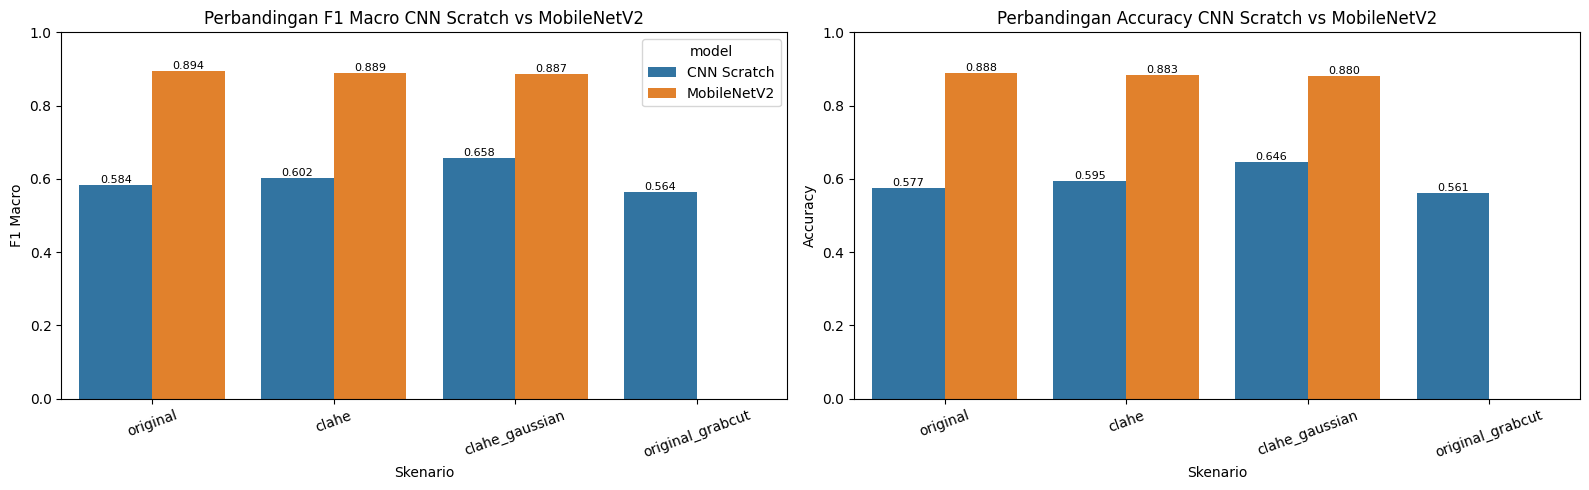

In [12]:
fig, ax = plt.subplots(
    1,
    2,
    figsize=(16, 5)
)

# F1 MACRO
sns.barplot(
    data=df_compare,
    x="scenario",
    y="f1_macro",
    hue="model",
    ax=ax[0]
)

ax[0].set_title(
    "Perbandingan F1 Macro CNN Scratch vs MobileNetV2"
)

ax[0].set_xlabel("Skenario")
ax[0].set_ylabel("F1 Macro")
ax[0].set_ylim(0, 1)

for container in ax[0].containers:
    ax[0].bar_label(
        container,
        fmt="%.3f",
        fontsize=8
    )

# ACCURACY
sns.barplot(
    data=df_compare,
    x="scenario",
    y="accuracy",
    hue="model",
    ax=ax[1]
)

ax[1].set_title(
    "Perbandingan Accuracy CNN Scratch vs MobileNetV2"
)

ax[1].set_xlabel("Skenario")
ax[1].set_ylabel("Accuracy")
ax[1].set_ylim(0, 1)

for container in ax[1].containers:
    ax[1].bar_label(
        container,
        fmt="%.3f",
        fontsize=8
    )

# RAPIIIN
for a in ax:
    a.tick_params(
        axis="x",
        rotation=20
    )

# hapus legend kanan supaya tidak dobel
ax[1].legend_.remove()

plt.tight_layout()

plt.savefig(
    DIR_FIGURES / "cnn_vs_mobilenet_comparison.png",
    dpi=120,
    bbox_inches="tight"
)

plt.show()